# 02 — Extração, análise e seleção de **features**

Para cada fruta segmentada extraímos um vetor de **features manuais** cobrindo as famílias pedidas (Aula 8): **forma**, **momentos de Hu (inerciais)**, **cor** e **textura**, além de **indicadores de podridão** (manchas escuras/marrons). Todas as estatísticas de cor/textura usam **apenas os pixels da máscara**.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 120); pd.set_option('display.max_columns', 60)
from src import config as cfg, dataset as ds, segmentation as seg, features as ft
from src import build_dataset
# (Re)gera X.csv e y.csv de forma reprodutível
build_dataset.main()

Amostra: 402 imagens (201 fresh / 201 rotten)
fruit   label_name
apple   fresh         67
        rotten        67
banana  fresh         67
        rotten        67
orange  fresh         67
        rotten        67
dtype: int64


  features 50/402


  features 100/402


  features 150/402


  features 200/402


  features 250/402


  features 300/402


  features 350/402


  features 400/402
  features 402/402

X.csv  -> C:\Users\User\Desktop\PipelineFrutas\outputs\X.csv  shape=(402, 56)
y.csv  -> C:\Users\User\Desktop\PipelineFrutas\outputs\y.csv  shape=(402, 3)
Cobertura media da mascara: 0.620 (min 0.162, max 1.000)
Concluido em 11.9s


In [2]:
X = pd.read_csv(cfg.OUTPUTS/'X.csv'); y = pd.read_csv(cfg.OUTPUTS/'y.csv')
feat = ft.all_feature_names()
print('X:', X.shape, '| nº de features:', len(feat))
print('\nFamílias de features:')
for g,cols in ft.FEATURE_GROUPS.items(): print(f'  {g:9s} ({len(cols)}): '+', '.join(cols))
display(X[feat].describe().T.head(12))

X: (402, 56) | nº de features: 52

Famílias de features:
  forma     (8): area_frac, perimeter_norm, eccentricity, solidity, extent, circularity, aspect_ratio, equiv_diam_norm
  hu        (7): hu1, hu2, hu3, hu4, hu5, hu6, hu7
  cor       (18): mean_R, std_R, mean_G, std_G, mean_B, std_B, mean_H, std_H, mean_S, std_S, mean_V, std_V, hue_hist0, hue_hist1, hue_hist2, hue_hist3, hue_hist4, hue_hist5
  textura   (16): glcm_contrast, glcm_homogeneity, glcm_energy, glcm_correlation, glcm_dissimilarity, glcm_ASM, lbp0, lbp1, lbp2, lbp3, lbp4, lbp5, lbp6, lbp7, lbp8, lbp9
  podridao  (3): dark_ratio, brown_ratio, sat_std


,count,mean,std,min,25%,50%,75%,max
area_frac,402.0,0.620147,0.204472,0.162039,0.500363,0.606475,0.705826,1.000000
perimeter_norm,402.0,2.418276,0.399343,1.641368,2.125407,2.350758,2.702720,4.252714
eccentricity,402.0,0.565616,0.215651,0.094376,0.398633,0.550354,0.743606,0.965168
solidity,402.0,0.908656,0.111273,0.467751,0.888292,0.949663,0.984982,1.000000
extent,402.0,0.741935,0.157093,0.313884,0.671750,0.763351,0.808397,1.000000
circularity,402.0,0.655264,0.177442,0.104984,0.534936,0.696333,0.789217,0.905759
aspect_ratio,402.0,1.237578,0.298240,1.000000,1.048282,1.120103,1.308397,3.069565
equiv_diam_norm,402.0,0.611322,0.107942,0.311370,0.560586,0.616167,0.666879,0.797863
hu1,402.0,3.137091,0.103216,2.757497,3.134305,3.180764,3.197002,3.204562
hu2,402.0,7.829245,1.045333,5.655562,7.120111,7.862950,8.524398,11.081603


## Coerência das features com o problema
Em *fresh × rotten*, esperamos que **cor** (escurecimento, manchas marrons) e **textura** (rugosidade, irregularidade da casca) separem melhor que a **forma**, já que a podridão altera principalmente a superfície.

## Boxplots por classe (features candidatas mais relevantes)

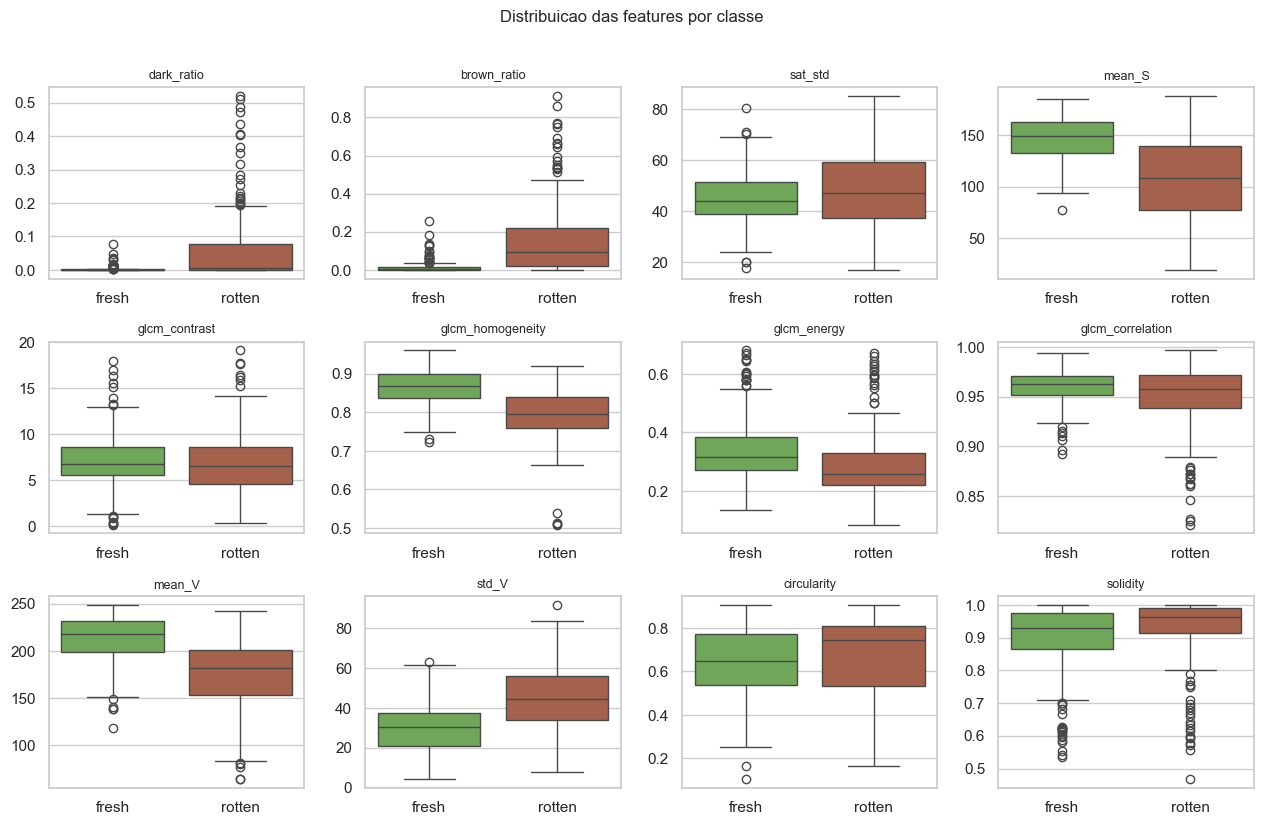

In [3]:
from src import plots
destaque = ['dark_ratio','brown_ratio','sat_std','mean_S',
            'glcm_contrast','glcm_homogeneity','glcm_energy','glcm_correlation',
            'mean_V','std_V','circularity','solidity']
plots.boxplots_by_class(X[feat], y['label'].values, destaque,
                        save_as='boxplots_features.png'); plt.show()

## Médias por classe e *effect size* (quais features separam melhor)

In [4]:
d = X[feat].copy(); d['label_name']=y['label_name']
means = d.groupby('label_name')[feat].mean().T
# Cohen's d como medida de separação
def cohend(a,b):
    na,nb=len(a),len(b); sp=np.sqrt(((na-1)*a.std()**2+(nb-1)*b.std()**2)/(na+nb-2))
    return (b.mean()-a.mean())/ (sp+1e-9)
fresh=X[feat][y.label==0]; rotten=X[feat][y.label==1]
means['cohen_d']=[cohend(fresh[f],rotten[f]) for f in feat]
means['abs_d']=means['cohen_d'].abs()
print('Top 12 features por poder de separação (|Cohen d|):')
display(means.sort_values('abs_d',ascending=False).head(12).round(3))

Top 12 features por poder de separação (|Cohen d|):


label_name,fresh,rotten,cohen_d,abs_d
glcm_homogeneity,0.867,0.791,-1.282,1.282
mean_S,146.896,106.757,-1.249,1.249
lbp2,0.020,0.036,1.194,1.194
mean_V,212.076,174.370,-1.152,1.152
std_V,29.666,45.282,1.072,1.072
brown_ratio,0.016,0.161,1.059,1.059
mean_R,207.863,173.001,-1.007,1.007
lbp5,0.248,0.215,-0.939,0.939
std_G,36.758,48.730,0.914,0.914
lbp0,0.009,0.016,0.875,0.875


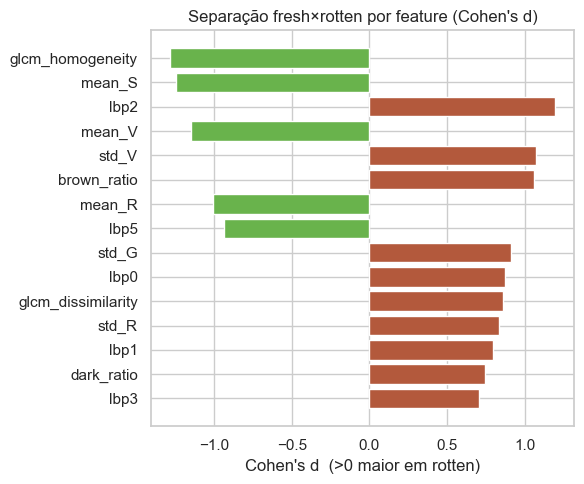

In [5]:
top = means.sort_values('abs_d',ascending=False).head(15)
fig,ax=plt.subplots(figsize=(6,5))
colors=['#b3593c' if v>0 else '#69b34c' for v in top['cohen_d']]
ax.barh(top.index[::-1], top['cohen_d'][::-1], color=colors[::-1])
ax.set_title("Separação fresh×rotten por feature (Cohen's d)")
ax.set_xlabel("Cohen's d  (>0 maior em rotten)")
fig.tight_layout(); fig.savefig(cfg.FEAT_DIR/'cohend_features.png',dpi=130); plt.show()

## Correlação entre features

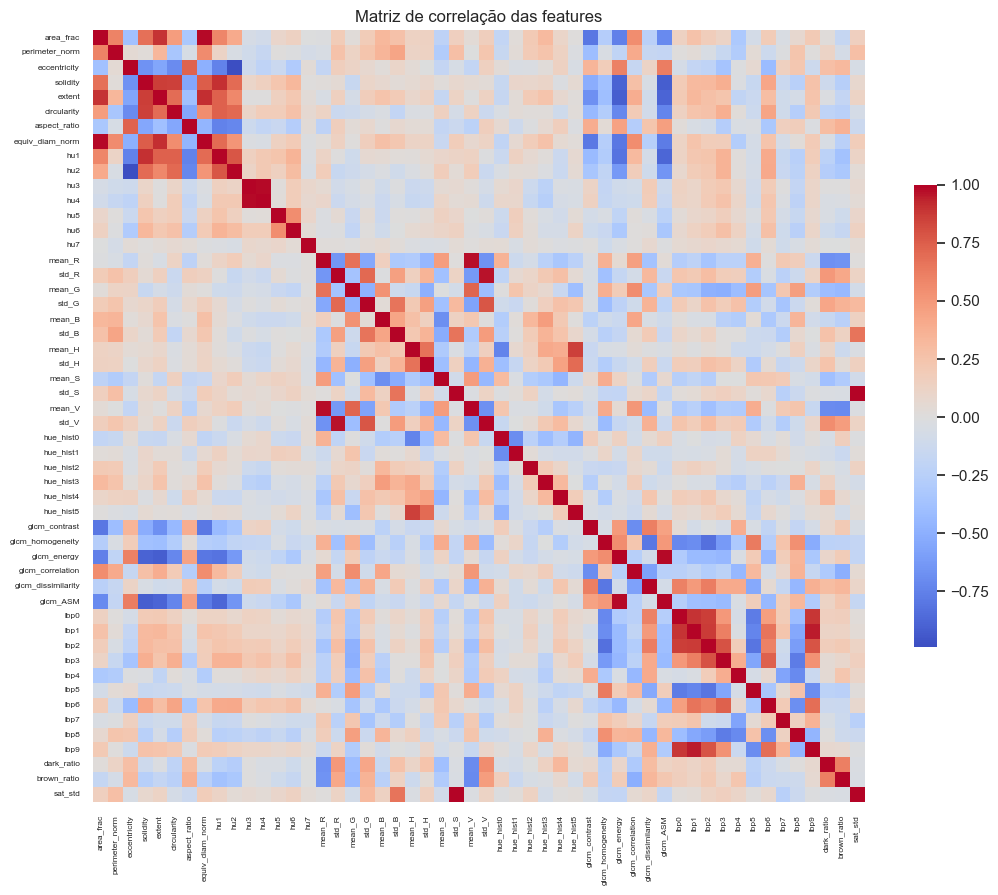

In [6]:
corr = X[feat].corr()
fig,ax=plt.subplots(figsize=(11,9))
sns.heatmap(corr,cmap='coolwarm',center=0,square=True,
            xticklabels=True,yticklabels=True,cbar_kws={'shrink':.6},ax=ax)
ax.set_title('Matriz de correlação das features'); plt.xticks(fontsize=6); plt.yticks(fontsize=6)
fig.tight_layout(); fig.savefig(cfg.FEAT_DIR/'correlacao.png',dpi=130); plt.show()

## PCA (visualização 2D) e comparação entre grupos de features

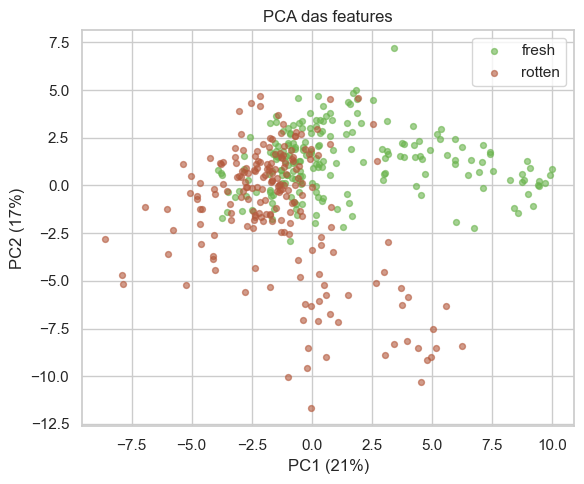

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
Z = StandardScaler().fit_transform(X[feat])
pca = PCA(n_components=2, random_state=cfg.RANDOM_STATE); P = pca.fit_transform(Z)
fig,ax=plt.subplots(figsize=(6,5))
for lab,co,nm in [(0,'#69b34c','fresh'),(1,'#b3593c','rotten')]:
    s=y.label==lab; ax.scatter(P[s,0],P[s,1],c=co,label=nm,alpha=.6,s=18)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
ax.set_title('PCA das features'); ax.legend()
fig.tight_layout(); fig.savefig(cfg.FEAT_DIR/'pca.png',dpi=130); plt.show()

In [8]:
# Comparação entre grupos de features (CV rápida com Random Forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
cvk = StratifiedKFold(5, shuffle=True, random_state=cfg.RANDOM_STATE)
combos = {'cor':['cor'],'textura':['textura'],'forma':['forma'],'hu':['hu'],
          'podridao':['podridao'],'cor+textura':['cor','textura'],
          'cor+textura+forma':['cor','textura','forma'],
          'TODAS':list(ft.FEATURE_GROUPS)}
res=[]
for nm,gs in combos.items():
    cols=[c for g in gs for c in ft.FEATURE_GROUPS[g]]
    sc=cross_val_score(RandomForestClassifier(300,random_state=cfg.RANDOM_STATE),
                       X[cols],y.label,cv=cvk,scoring='f1')
    res.append({'grupo':nm,'n_feats':len(cols),'F1_cv':sc.mean(),'std':sc.std()})
grp=pd.DataFrame(res).sort_values('F1_cv',ascending=False)
grp.to_csv(cfg.METRIC_DIR/'comparacao_grupos_features.csv',index=False)
display(grp.round(3))

,grupo,n_feats,F1_cv,std
5,cor+textura,34,0.928,0.037
7,TODAS,52,0.928,0.031
6,cor+textura+forma,42,0.920,0.050
0,cor,18,0.899,0.011
1,textura,16,0.859,0.037
4,podridao,3,0.798,0.041
2,forma,8,0.599,0.041
3,hu,7,0.568,0.041


## Conclusões da análise de features

- As features de **cor** e **podridão** (`dark_ratio`, `brown_ratio`, `mean_S`, `mean_V`) e de **textura** (GLCM `contrast`/`homogeneity`) têm os maiores *effect sizes* — coerente com o problema, pois a podridão muda cor e textura.
- A **forma** e os **momentos de Hu** separam pouco (frutas frescas e podres têm contornos parecidos), mas mantemos uma família de cada tipo conforme o enunciado.
- `cor+textura` já alcança quase o desempenho de *todas* as features.

Os arquivos **`outputs/X.csv`** e **`outputs/y.csv`** ficam prontos para o notebook 03.